Decision Tree - Train Accuracy: 0.875
Decision Tree - Test Accuracy: 0.5
Random Forest - Train Accuracy: 0.875
Random Forest - Test Accuracy: 0.75


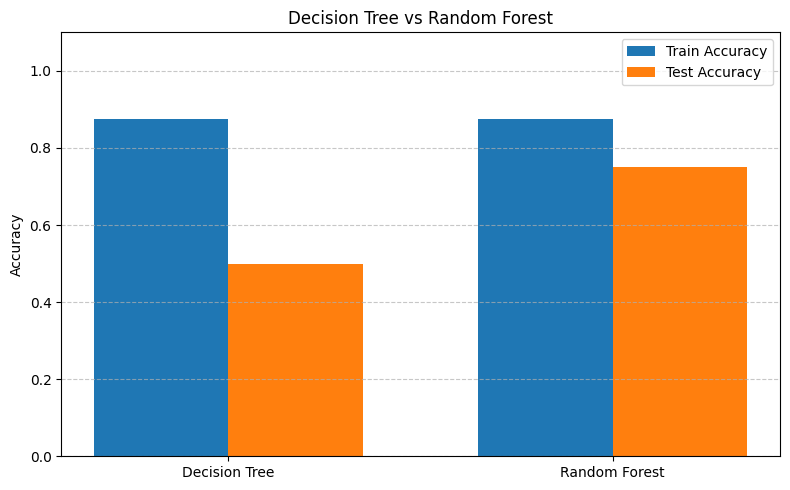

In [3]:
# === 1. Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# === 2. Create dataset ===
# Normal pattern: students who study and sleep well pass
data = {
    'StudyHours':     [8, 7, 9, 10, 6, 2, 1, 3, 4, 5, 8],  # Feature 1
    'SleepHours':     [7, 6, 8, 7, 6, 3, 2, 2, 3, 4, 7],   # Feature 2
    'Pass':           [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]    # Label: 1 = Pass, 0 = Fail
}

df = pd.DataFrame(data)

# Add one noisy data point: studied well & slept well but still failed
df.loc[len(df)] = [9, 8, 0]  # This is the noisy case

# === 3. Prepare data ===
X = df[['StudyHours', 'SleepHours']]
y = df['Pass']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# === 4. Train Decision Tree ===
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

# === 5. Train Random Forest ===
rforest = RandomForestClassifier(n_estimators=100, random_state=42)
rforest.fit(X_train, y_train)

# === 6. Predictions & Accuracy ===
# Decision Tree
y_pred_dt_train = dtree.predict(X_train)
y_pred_dt_test = dtree.predict(X_test)

# Random Forest
y_pred_rf_train = rforest.predict(X_train)
y_pred_rf_test = rforest.predict(X_test)

# === 7. Print Accuracy ===
print("Decision Tree - Train Accuracy:", accuracy_score(y_train, y_pred_dt_train))
print("Decision Tree - Test Accuracy:", accuracy_score(y_test, y_pred_dt_test))

print("Random Forest - Train Accuracy:", accuracy_score(y_train, y_pred_rf_train))
print("Random Forest - Test Accuracy:", accuracy_score(y_test, y_pred_rf_test))

# === 8. Plot Accuracy Comparison ===
models = ['Decision Tree', 'Random Forest']
train_acc = [
    accuracy_score(y_train, y_pred_dt_train),
    accuracy_score(y_train, y_pred_rf_train)
]
test_acc = [
    accuracy_score(y_test, y_pred_dt_test),
    accuracy_score(y_test, y_pred_rf_test)
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, train_acc, width, label='Train Accuracy')
plt.bar(x + width/2, test_acc, width, label='Test Accuracy')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Decision Tree vs Random Forest')
plt.xticks(x, models)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
